# **Laboratorio 07**

# **Regresión**

**Definición del problema**

El objetivo de este análisis es construir un modelo de regresión capaz de predecir el valor medio de las viviendas (target) a partir de las características disponibles del conjunto de datos de California Housing, como el ingreso medio de los hogares, la antigüedad de las viviendas, el número promedio de habitaciones, la población y la ubicación geográfica. Posteriormente, se compararán distintos modelos de regresión para determinar cuál ofrece el mejor desempeño predictivo utilizando métricas de evaluación apropiadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):

    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [8]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Estadística descriptiva**

In [9]:
# Dimensiones del DataFrame
print("Dimensiones del dataset:")
print(f"Filas: {housing.shape[0]}")
print(f"Columnas: {housing.shape[1]}")

print("\n" + "="*50)

# Información general
print("Información general:")
housing.info()

print("\n" + "="*50)

# Resumen estadístico
print("Resumen estadístico:")
display(housing.describe())

print("\n" + "="*50)

# Valores nulos
print("Valores nulos por columna:")
print(housing.isnull().sum())

print("\n" + "="*50)

# Tipos de datos
print("Tipos de datos:")
print(housing.dtypes)

Dimensiones del dataset:
Filas: 20640
Columnas: 9

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Resumen estadístico:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Valores nulos por columna:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

Tipos de datos:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object


**Visualización descriptiva**

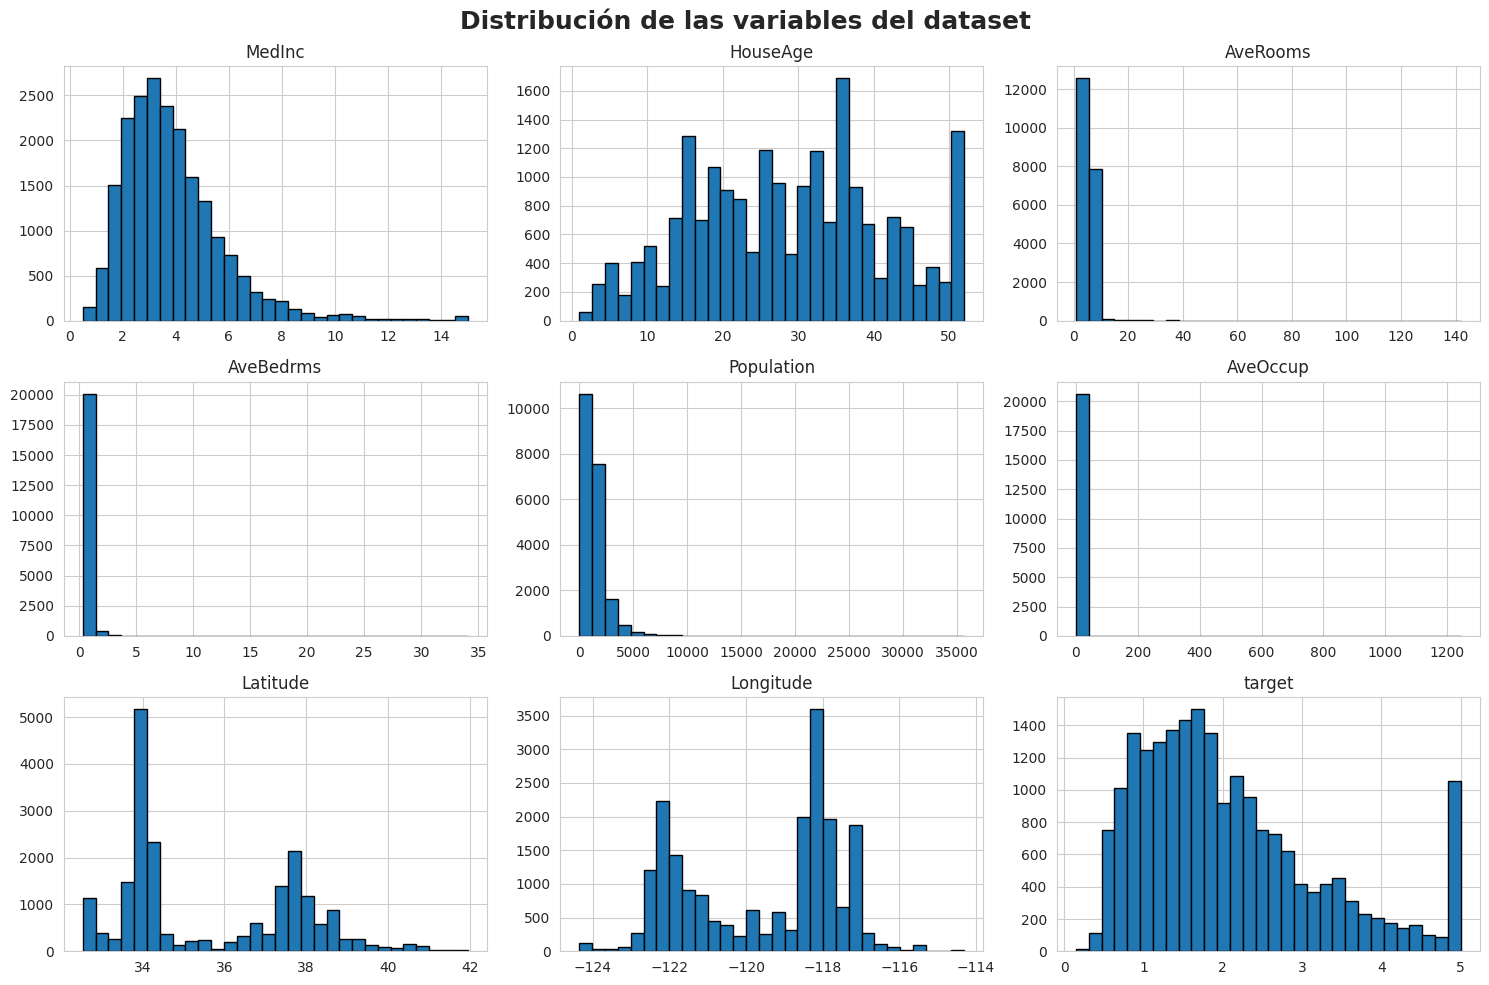

In [10]:
# Histogramas de todas las variables

housing.hist(
    figsize=(15,10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribución de las variables del dataset", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

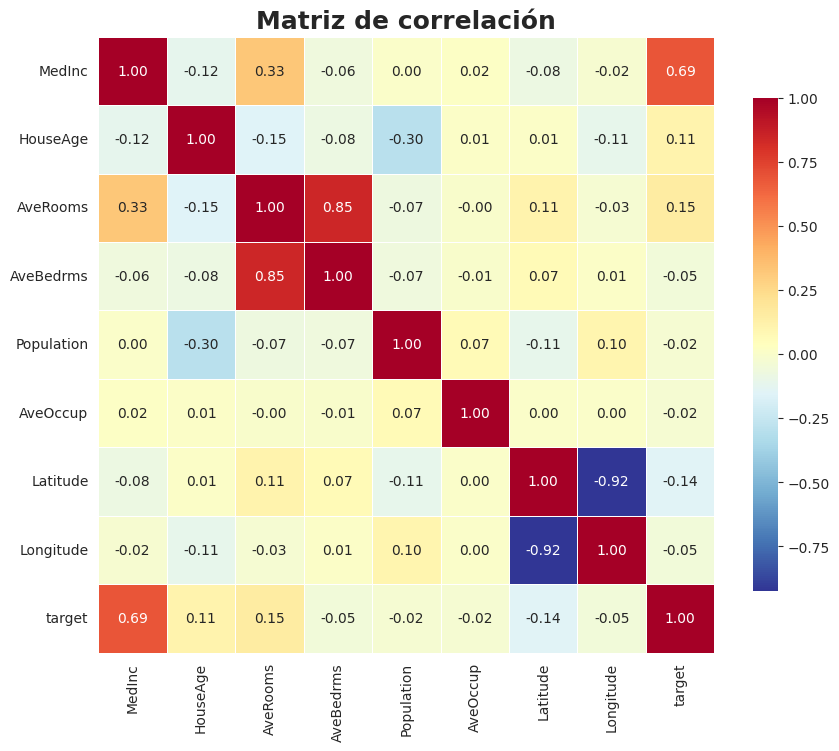

In [11]:
plt.figure(figsize=(10,8))

corr = housing.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Matriz de correlación", fontsize=18, fontweight="bold")
plt.show()

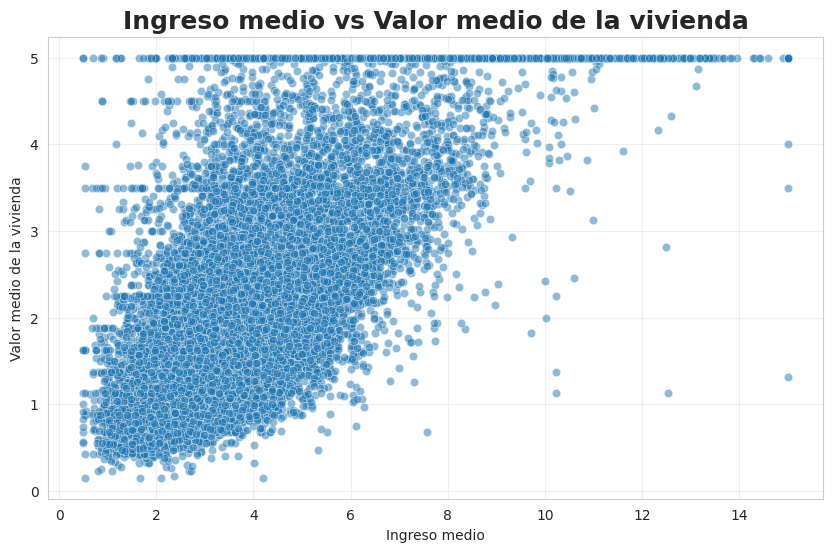

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=housing,
    x="MedInc",
    y="target",
    alpha=0.5
)

plt.title("Ingreso medio vs Valor medio de la vivienda", fontsize=18, fontweight="bold")
plt.xlabel("Ingreso medio")
plt.ylabel("Valor medio de la vivienda")
plt.grid(alpha=0.3)

plt.show()

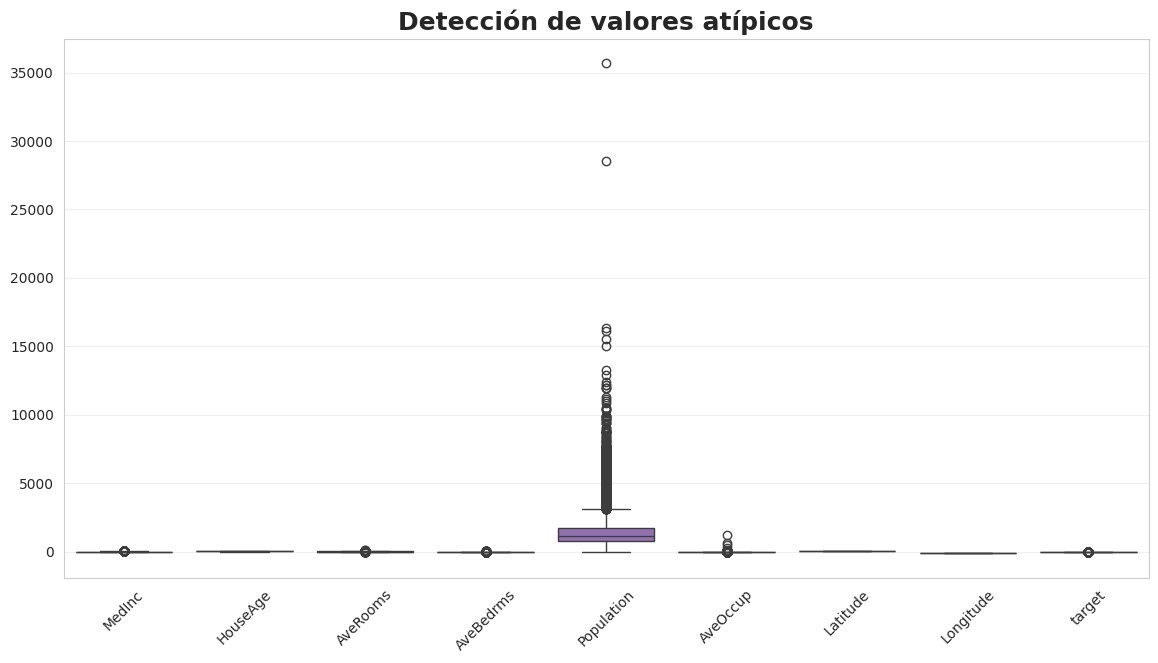

In [13]:
plt.figure(figsize=(14,7))

sns.boxplot(data=housing)

plt.xticks(rotation=45)
plt.title("Detección de valores atípicos", fontsize=18, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Preprocesamiento**

In [14]:
# Verificar valores faltantes
housing.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


In [15]:
# Variables predictoras y variable objetivo

X = housing.drop(columns="target")
y = housing["target"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (16512, 8)
Prueba: (4128, 8)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled
X_test_scaled

y_train
y_test

,target
20046,0.47700
3024,0.45800
15663,5.00001
20484,2.18600
9814,2.78000
...,...
15362,2.63300
16623,2.66800
18086,5.00001
2144,0.72300


**Selección de modelo**

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Diccionario con los modelos
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

In [20]:
resultados = []

for nombre, modelo in modelos.items():

    # Entrenar
    modelo.fit(X_train_scaled, y_train)

    # Predicción
    yhat = modelo.predict(X_test_scaled)

    # Calcular métricas
    df_eval = pd.DataFrame({
        "y": y_test,
        "yhat": yhat
    })

    metricas = regression_metrics(df_eval)
    metricas.insert(0, "Modelo", nombre)

    resultados.append(metricas)

# Unir resultados
resultados = pd.concat(resultados, ignore_index=True)

display(resultados)

,Modelo,mae,mse,rmse,mape,smape
0,Regresión Lineal,0.5332,0.5559,0.7456,31.9522,0.4843
1,Árbol de Decisión,0.4539,0.4940,0.7028,24.8768,0.3984
2,Random Forest,0.3274,0.2552,0.5051,18.9090,0.3180
3,KNN,0.4462,0.4324,0.6576,24.6681,0.3957


**Métricas y análisis de resultados**

In [24]:
# Evaluación de los modelos

resultados = []

for nombre, modelo in modelos.items():

    # Entrenar
    modelo.fit(X_train_scaled, y_train)

    # Predecir
    yhat = modelo.predict(X_test_scaled)

    # Crear DataFrame para calcular métricas
    df_metricas = pd.DataFrame({
        "y": y_test,
        "yhat": yhat
    })

    # Calcular métricas
    metricas = regression_metrics(df_metricas)
    metricas.insert(0, "Modelo", nombre)

    resultados.append(metricas)

# Unir todos los resultados
resultados = pd.concat(resultados, ignore_index=True)

# Mostrar resultados
display(resultados)

,Modelo,mae,mse,rmse,mape,smape
0,Regresión Lineal,0.5332,0.5559,0.7456,31.9522,0.4843
1,Árbol de Decisión,0.4539,0.4940,0.7028,24.8768,0.3984
2,Random Forest,0.3274,0.2552,0.5051,18.9090,0.3180
3,KNN,0.4462,0.4324,0.6576,24.6681,0.3957


**Visualización de resultados del modelo**

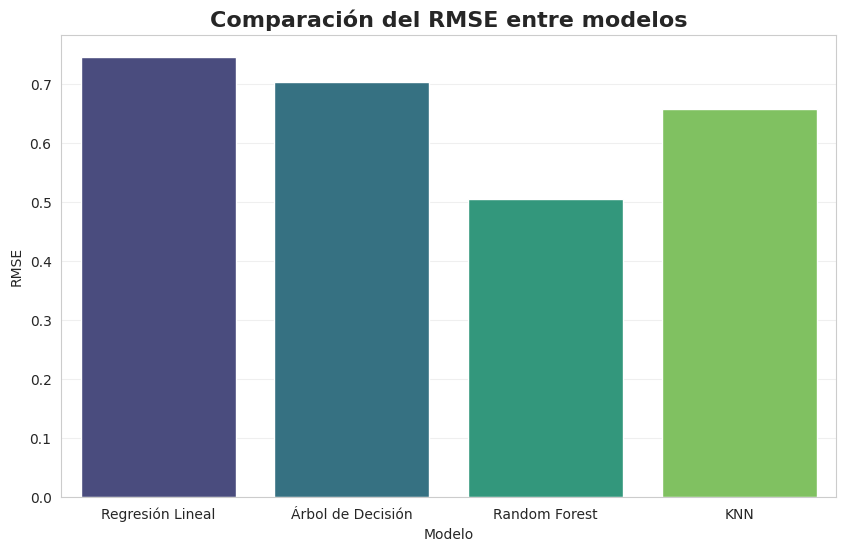

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="rmse",
    hue="Modelo",
    palette="viridis",
    legend=False
)

plt.title("Comparación del RMSE entre modelos", fontsize=16, fontweight="bold")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)

plt.show()

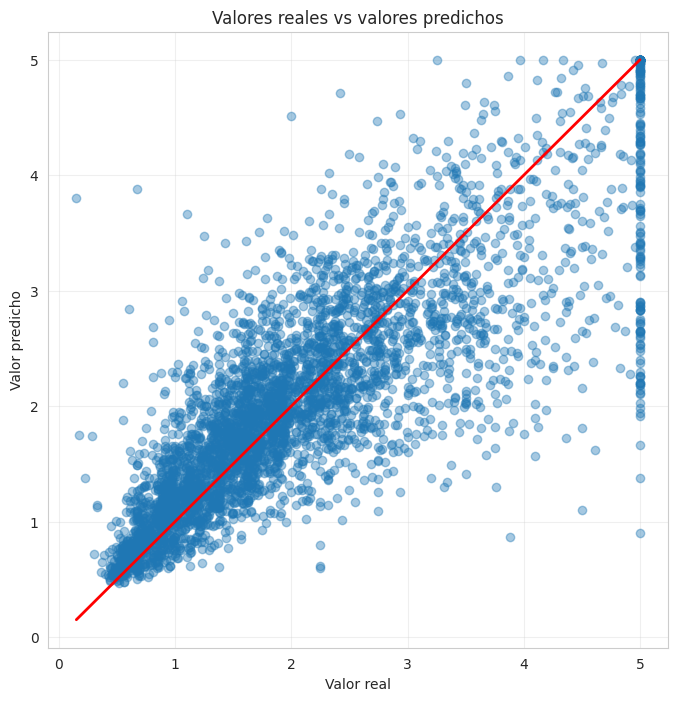

In [23]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, yhat, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Valores reales vs valores predichos")

plt.grid(alpha=0.3)

plt.show()

**Conclusiones**

A partir de las métricas obtenidas, se observa que el modelo Random Forest presentó el mejor desempeño predictivo entre los cuatro modelos evaluados. Este modelo obtuvo los menores valores de error en todas las métricas analizadas (MAE = 0.3274, MSE = 0.2552, RMSE = 0.5051, MAPE = 18.91% y sMAPE = 0.3180), lo que indica una mayor precisión al estimar el valor de las viviendas.

La Regresión Lineal fue el modelo con el rendimiento más bajo, presentando los mayores errores en todas las métricas evaluadas. Esto sugiere que la relación entre las variables explicativas y el valor de las viviendas no es completamente lineal, por lo que un modelo lineal resulta insuficiente para capturar toda la complejidad de los datos.

Por su parte, el Árbol de Decisión y K-Nearest Neighbors (KNN) mostraron un desempeño intermedio. Aunque ambos mejoran los resultados obtenidos por la Regresión Lineal, presentan errores considerablemente superiores a los del modelo Random Forest, lo que evidencia una menor capacidad predictiva.

En conclusión, el modelo Random Forest es la alternativa más adecuada para este conjunto de datos, ya que logra las predicciones más precisas y consistentes. Los resultados demuestran además la importancia de comparar distintos algoritmos de Machine Learning, puesto que modelos capaces de capturar relaciones no lineales pueden ofrecer un rendimiento significativamente superior al de los modelos lineales tradicionales.

#**Clasificación**

In [25]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [26]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [27]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [28]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

In [29]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


**Análisis exploratorio**

In [30]:
# Dimensiones
print("Dimensiones del dataset:")
print(f"Filas: {digits.shape[0]}")
print(f"Columnas: {digits.shape[1]}")

print("\n" + "="*50)

# Información general
print("Información general:")
digits.info()

print("\n" + "="*50)

# Tipos de datos
print("Tipos de datos:")
print(digits.dtypes)

print("\n" + "="*50)

# Consumo de memoria
print("Memoria utilizada:")
print(digits.memory_usage(deep=True))
print(f"\nTotal: {digits.memory_usage(deep=True).sum()/1024:.2f} KB")

print("\n" + "="*50)

# Resumen estadístico
print("Resumen estadístico:")
display(digits.describe())

print("\n" + "="*50)

# Valores nulos
print("Valores nulos por columna:")
print(digits.isnull().sum())

print("\n" + "="*50)

# Registros por clase
print("Cantidad de registros por dígito:")
display(digits["target"].value_counts().sort_index())

Dimensiones del dataset:
Filas: 1797
Columnas: 65

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     179

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000



Valores nulos por columna:
c00       0
c01       0
c02       0
c03       0
c04       0
         ..
c60       0
c61       0
c62       0
c63       0
target    0
Length: 65, dtype: int64

Cantidad de registros por dígito:


,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


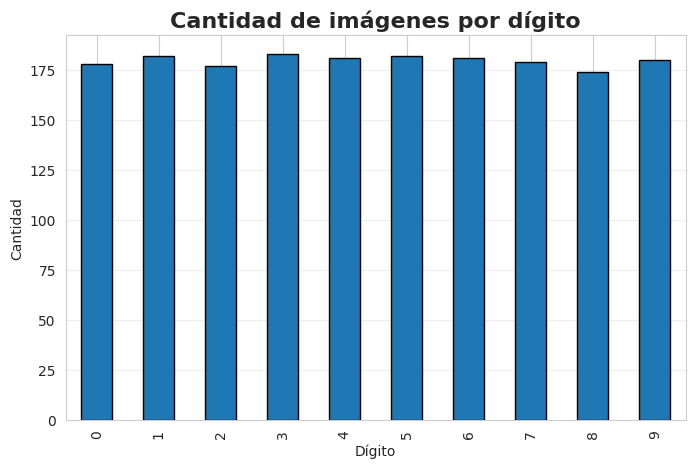

In [31]:
plt.figure(figsize=(8,5))

digits["target"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Cantidad de imágenes por dígito", fontsize=16, fontweight="bold")
plt.xlabel("Dígito")
plt.ylabel("Cantidad")
plt.grid(axis="y", alpha=0.3)

plt.show()

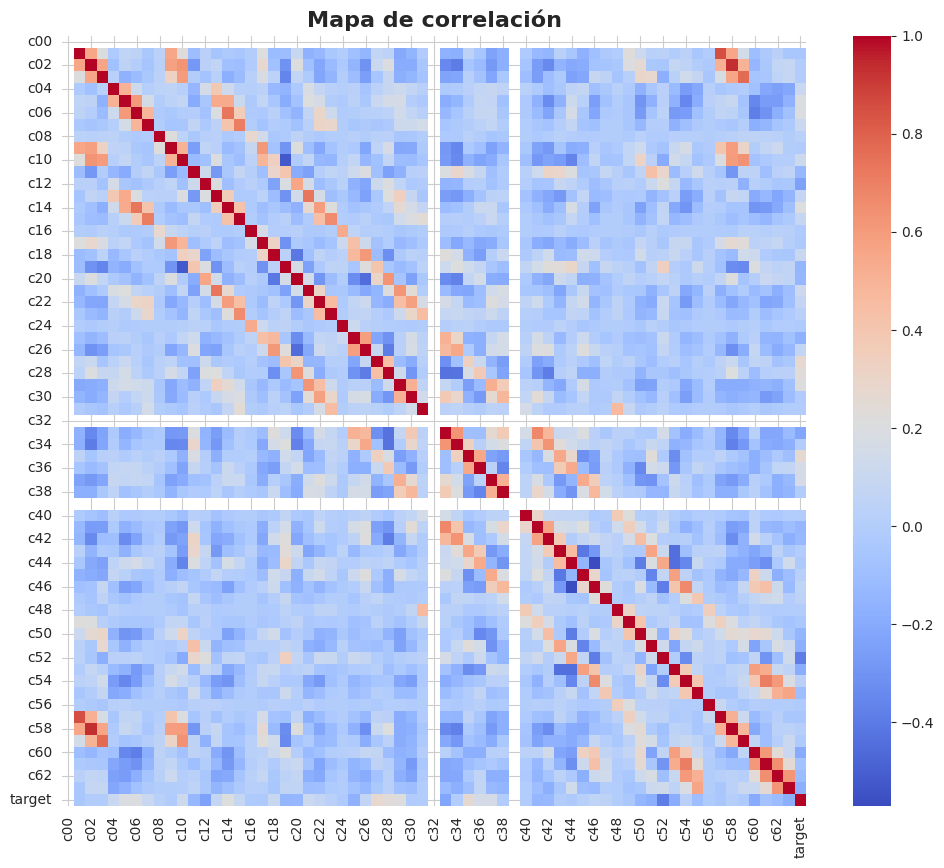

In [32]:
plt.figure(figsize=(12,10))

corr = digits.corr()

import seaborn as sns

sns.heatmap(
    corr,
    cmap="coolwarm",
    cbar=True
)

plt.title("Mapa de correlación", fontsize=16, fontweight="bold")

plt.show()

**Visualización**

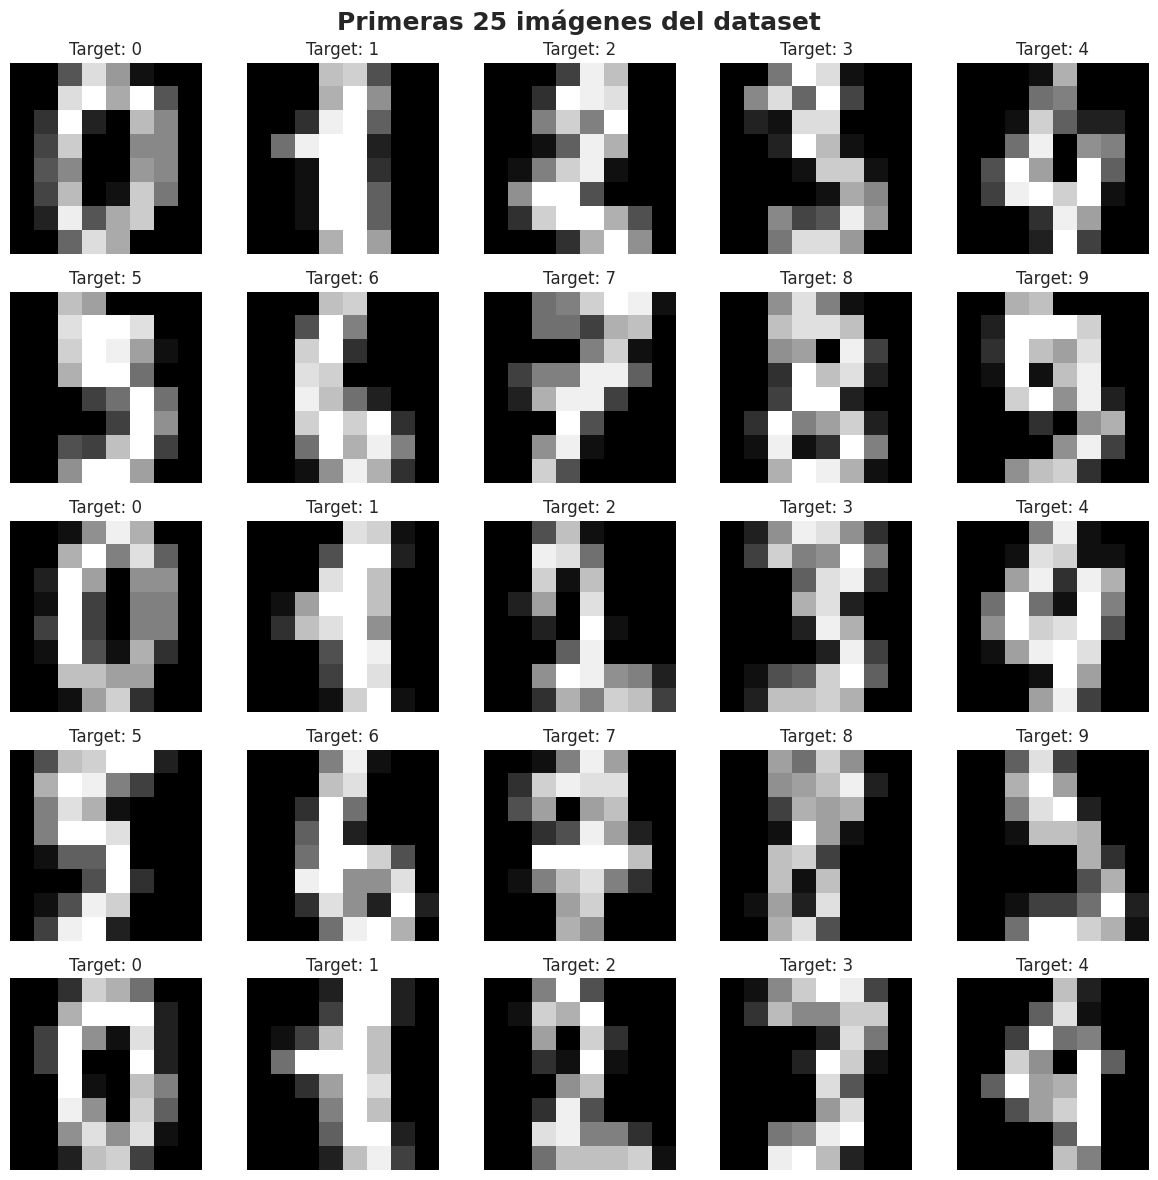

In [33]:
# Visualizar las primeras 25 imágenes

nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i, ax in enumerate(axs.flat):

    # Mostrar la imagen (convertir de 64 a 8x8)
    ax.imshow(digits_dict["images"][i], cmap="gray")

    # Mostrar el label correspondiente
    ax.set_title(f"Target: {digits_dict['target'][i]}")

    # Quitar ejes para una mejor visualización
    ax.axis("off")

plt.suptitle("Primeras 25 imágenes del dataset", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Comprensión del modelo**

In [36]:
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

In [37]:
# Features y target
X = digits.drop(columns="target").values
y = digits["target"].values

In [38]:
from sklearn.model_selection import train_test_split

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Cantidad de datos de entrenamiento:", len(X_train))
print("Cantidad de datos de prueba:", len(X_test))

Cantidad de datos de entrenamiento: 1437
Cantidad de datos de prueba: 360


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [41]:
import time

modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

tiempos = {}

for nombre, modelo in modelos.items():

    inicio = time.time()

    modelo.fit(X_train, y_train)

    fin = time.time()

    tiempos[nombre] = fin - inicio

print("Tiempo de entrenamiento:")
for nombre, tiempo in tiempos.items():
    print(f"{nombre}: {tiempo:.4f} segundos")

Tiempo de entrenamiento:
Regresión Logística: 1.9895 segundos
KNN: 0.0013 segundos
Random Forest: 0.7431 segundos


In [42]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

resultados = []

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    })

resultados = pd.DataFrame(resultados)

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.958333,0.958988,0.958333,0.958363
1,KNN,0.983333,0.983612,0.983333,0.983247
2,Random Forest,0.961111,0.961996,0.961111,0.960940


<Figure size 800x800 with 0 Axes>

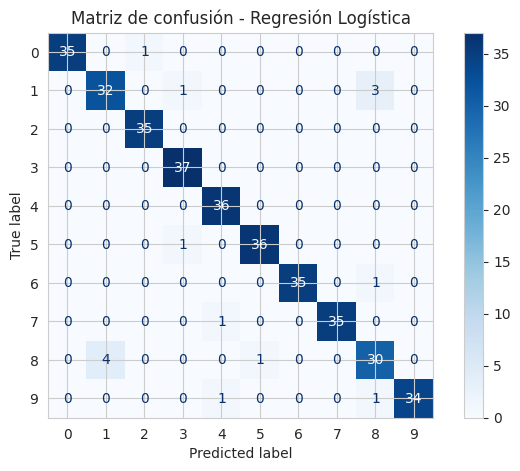

<Figure size 800x800 with 0 Axes>

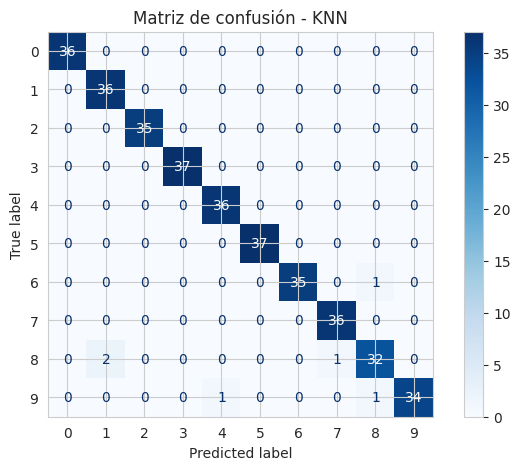

<Figure size 800x800 with 0 Axes>

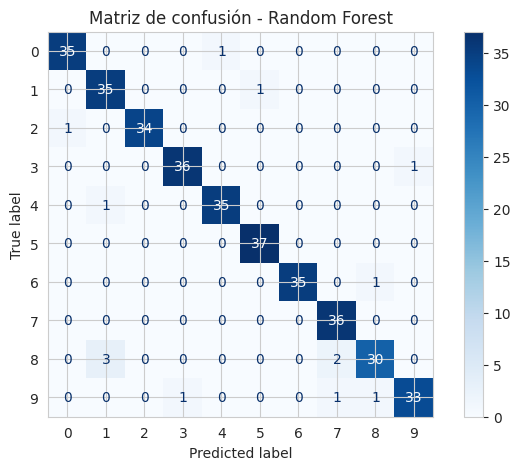

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    plt.figure(figsize=(8,8))
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

**Comprensión del modelo**

Los resultados obtenidos evidencian un desempeño elevado de los tres modelos evaluados en la tarea de clasificación de dígitos, con valores de accuracy, precision, recall y F1-score superiores al 95% en todos los casos. Esto indica que el problema presenta una estructura bien definida, permitiendo una correcta separación entre clases a partir de las variables disponibles.

En particular, el modelo K-Nearest Neighbors (KNN) presenta el mejor rendimiento global, alcanzando un accuracy de 0.9833 y un F1-score de 0.9832. Este resultado sugiere que la similitud entre observaciones es una característica altamente relevante para la clasificación de dígitos, lo que permite que el modelo aproveche eficazmente la proximidad entre los datos en el espacio de características.

Por otro lado, la regresión logística obtiene un desempeño ligeramente inferior, con un accuracy de 0.9583. A pesar de su simplicidad, el modelo presenta resultados competitivos, lo que indica que existe cierta separabilidad lineal en los datos. Sin embargo, su capacidad para capturar relaciones más complejas es limitada en comparación con otros enfoques.

El modelo Random Forest obtiene un rendimiento intermedio, con un accuracy de 0.9611. Si bien es capaz de modelar relaciones no lineales, en este caso no supera el desempeño del modelo basado en vecinos más cercanos, lo que sugiere que la estructura del problema favorece enfoques basados en distancia.

En términos generales, los resultados permiten establecer el siguiente orden de desempeño: KNN como mejor modelo, seguido por Random Forest y finalmente regresión logística. No obstante, la elección del modelo final también debe considerar aspectos como la interpretabilidad, el costo computacional y la escalabilidad, además del rendimiento predictivo.

En conclusión, KNN se presenta como el modelo más adecuado para este conjunto de datos en términos de precisión, mientras que la regresión logística puede ser una alternativa viable cuando se prioriza simplicidad e interpretabilidad.

**Visualizando resultados**

In [44]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):


    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

In [45]:
from sklearn.neighbors import KNeighborsClassifier

# Modelo (mejor encontrado)
best_model = KNeighborsClassifier()
best_model.fit(X_train, y_train)

# Predicciones
y_pred = best_model.predict(X_test)

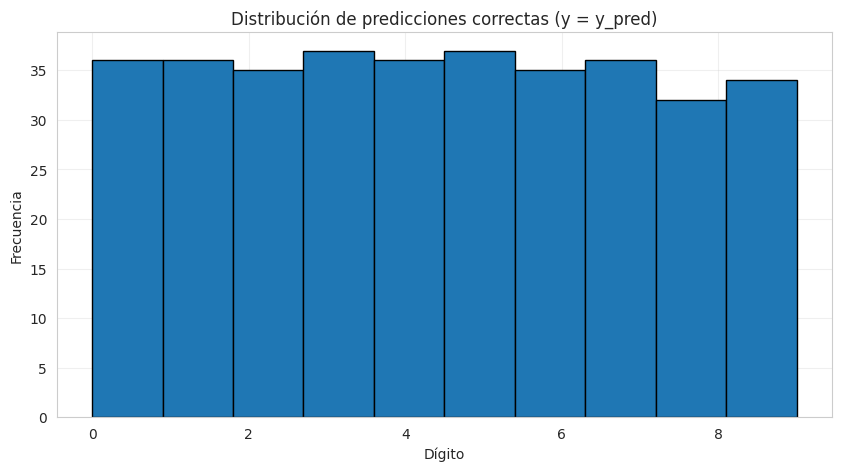

In [46]:
import matplotlib.pyplot as plt

correctos = (y_test == y_pred)

plt.figure(figsize=(10,5))
plt.hist(y_test[correctos], bins=10, edgecolor="black")

plt.title("Distribución de predicciones correctas (y = y_pred)")
plt.xlabel("Dígito")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)

plt.show()

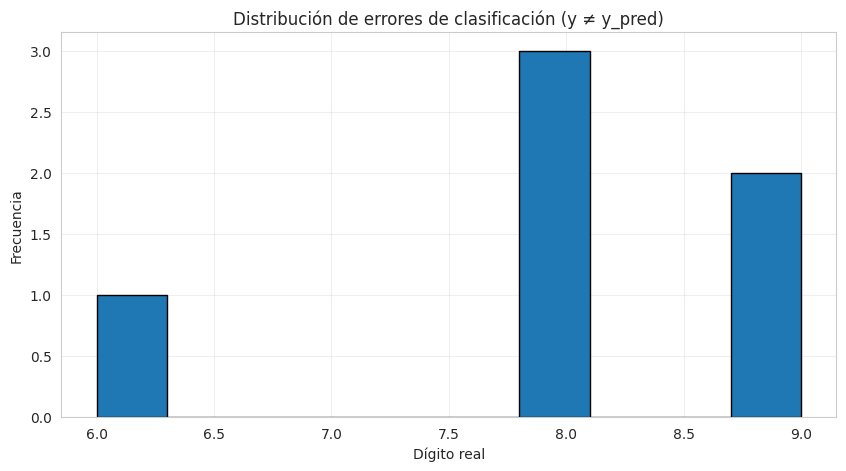

In [47]:
incorrectos = (y_test != y_pred)

plt.figure(figsize=(10,5))
plt.hist(y_test[incorrectos], bins=10, edgecolor="black")

plt.title("Distribución de errores de clasificación (y ≠ y_pred)")
plt.xlabel("Dígito real")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)

plt.show()

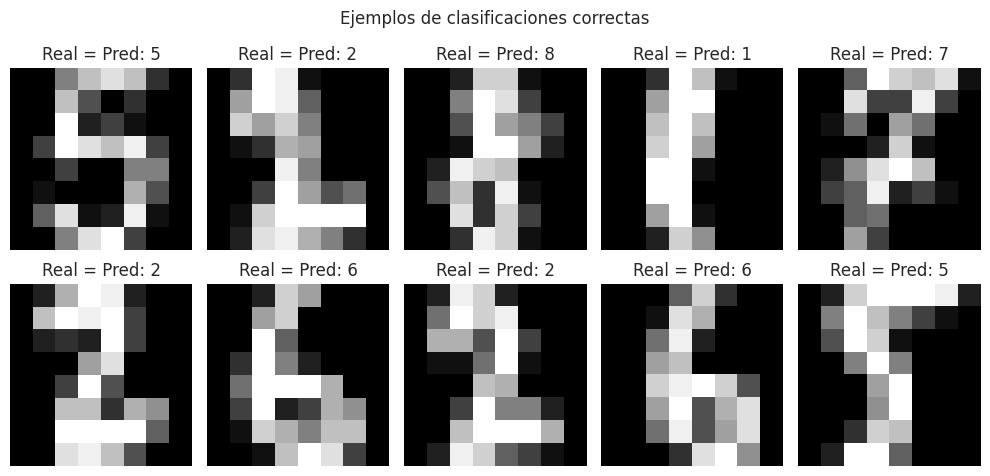

In [48]:
import numpy as np

idx_correctos = np.where(correctos)[0]

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img = X_test[idx_correctos[i]].reshape(8,8)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Real = Pred: {y_test[idx_correctos[i]]}")
    ax.axis("off")

plt.suptitle("Ejemplos de clasificaciones correctas")
plt.tight_layout()
plt.show()

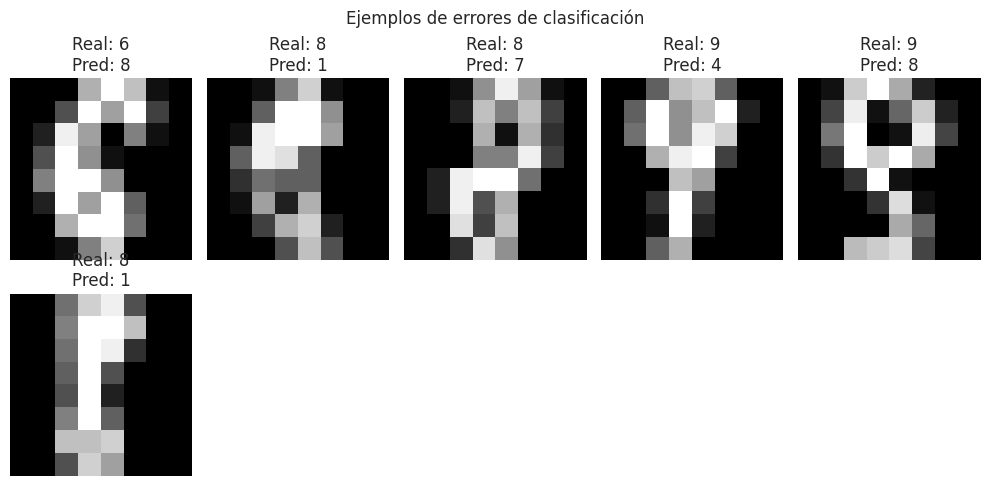

In [50]:
idx_incorrectos = np.where(incorrectos)[0]

n = min(len(idx_incorrectos), 10)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flat

for i in range(n):
    img = X_test[idx_incorrectos[i]].reshape(8,8)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(
        f"Real: {y_test[idx_incorrectos[i]]}\nPred: {y_pred[idx_incorrectos[i]]}"
    )
    axes[i].axis("off")

# Ocultar ejes vacíos si hay menos de 10 errores
for j in range(n, 10):
    axes[j].axis("off")

plt.suptitle("Ejemplos de errores de clasificación")
plt.tight_layout()
plt.show()

El bajo número de errores observados confirma el alto desempeño del modelo KNN en la tarea de clasificación. Las pocas fallas se explican principalmente por la similitud visual entre ciertos dígitos y la representación limitada de las imágenes en un espacio de 64 características.